In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import acf, q_stat, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import re
import scipy.stats as stats



## Visualisations of Returns

In [ ]:
def ts_plot(series : pd.Series, max_lags : int, title : str):
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot the series
    axs[0, 0].plot(series)
    axs[0, 0].set_title('Series')

    # QQPLOT
    qqplot(series, ax = axs[0, 1], line='s')
    axs[0, 1].set_title('QQ plot', size = 10)

    # ACF PLOT
    plot_acf(series, lags=max_lags, ax = axs[1, 0], zero=False) # zero = False to not include lag 0
    axs[1, 0].set_title('Autocorrelation plot', size = 10)
    axs[1, 0].set_xlabel('Lag')

    # PACF PLOT
    plot_pacf(series, lags=max_lags, ax = axs[1, 1], zero=False)
    axs[1, 1].set_title('Partial Autocorrelation plot', size = 10)
    axs[1, 1].set_xlabel('Lag', size = 10)

    fig.suptitle(title, fontsize=20) # add a superior title for the figure
    # autoscale both correlation plots
    axs[1, 0].autoscale()
    axs[1, 1].autoscale()

    plt.tight_layout()

In [ ]:
def make_descriptive_table(df: pd.DataFrame):

    stats_dict = {
        'Obs.':       [],
        'Max':        [],
        'Mean':       [],
        'Median':     [],
        'Min':        [],
        'SD':         [],
        'Skew':       [],
        'Kurtosis':   [],
        'AC(1)':      []
    }
    names = []  # to store the column names in order

    for col in df.columns:
        series = df[col].dropna()  # drop missing so counts, etc., are correct
        if len(series) == 0:
            # if the entire column is empty, fill with NaNs
            obs = 0
            max_val = mean_val = median_val = min_val = sd = skew = kurt = ac1 = np.nan
        else:
            obs = series.count()
            max_val = series.max()
            mean_val = series.mean()
            median_val = series.median()
            min_val = series.min()
            # Use ddof=1 by default for “sample” SD (matching most economic papers)
            sd = series.std(ddof=1)
            # Fisher’s skewness and excess kurtosis via scipy.stats
            skew = series.skew()         # pandas’ .skew() is Fisher’s
            kurt = series.kurtosis()     # pandas’ .kurtosis() is excess kurtosis
            # First-lag autocorrelation (pandas’ .autocorr or numpy.corrcoef)
            # Here we use pandas’ built-in:
            ac1 = series.autocorr(lag=1)

        # Append to lists
        names.append(col)
        stats_dict['Obs.'].append(obs)
        stats_dict['Max'].append(max_val)
        stats_dict['Mean'].append(mean_val)
        stats_dict['Median'].append(median_val)
        stats_dict['Min'].append(min_val)
        stats_dict['SD'].append(sd)
        stats_dict['Skew'].append(skew)
        stats_dict['Kurtosis'].append(kurt)
        stats_dict['AC(1)'].append(ac1)

    # Build the final DataFrame
    desc_df = pd.DataFrame(index=names, data=stats_dict)

    # Reorder the columns exactly as in the table spec:
    desc_df = desc_df[['Obs.', 'Max', 'Mean', 'Median', 'Min', 'SD', 'Skew', 'Kurtosis', 'AC(1)']]

    return desc_df

In [ ]:
def plot_distribution_comparison(
    data,
    main_title="Comparison vs. Standard Normal",
    tail_title="Left Tail ",
    center_title="Central Tendency",
    xlim_main=(-0.10, 0.10),
    xlim_tail=(-0.08, -0.03),
    xlim_center=(-0.025, 0.025),
    figsize=(20, 16),
):
    """
    Plots a 2x2 grid:
      - Top-wide: histogram + KDE of `data` overlaid with a fitted standard normal PDF.
      - Bottom-left: zoom on the left tail compared to normal.
      - Bottom-right: zoom on the center (leptokurtic spike) compared to normal.
    """

    # Compute sample mean & std once
    mu = np.mean(data)
    sigma = np.std(data, ddof=0)  # population std to match normal pdf

    # Create figure + 2x2 gridspec
    fig, axs = plt.subplots(2, 2, figsize=figsize)
    gs = fig.add_gridspec(2, 2)
    
    # Top row: one subplot spanning both columns
    ax_main = fig.add_subplot(gs[0, :])
    axs[0, 0].set_yticks([])  # hide unused
    axs[0, 0].set_xticks([])
    axs[0, 1].set_xticks([])
    axs[0, 1].set_yticks([])
    
    # Plot histogram+KDE of data on the wide top axis
    sns.histplot(data, stat='density', kde=True, label='Data Distribution', ax=ax_main)
    ax_main.set_xlim(xlim_main)
    
    # Overlay standard normal PDF
    x_main = np.linspace(xlim_main[0], xlim_main[1], 1000)
    p_main = stats.norm.pdf(x_main, loc=mu, scale=sigma)
    ax_main.plot(x_main, p_main, 'r', linewidth=2, label='Standard Normal')
    ax_main.legend()
    
    # Annotate skewness + kurtosis
    skew = stats.skew(data)
    kurt = stats.kurtosis(data, fisher=True)  # excess kurtosis
    textstr = f"SKEWNESS: {skew:.3f}\nKURTOSIS: {kurt:.3f}"
    ax_main.text(
        xlim_main[0] + (xlim_main[1]-xlim_main[0])*0.05,
        ax_main.get_ylim()[1]*0.7,
        textstr,
        bbox={'alpha': 0.5, 'pad': 10},
        fontsize=15
    )
    
    ax_main.set_title(main_title, fontsize=20, fontweight='bold')
    
    # Bottom-left: Fat tail zoom
    ax_tail = axs[1, 0]
    sns.histplot(data, stat='density', kde=True, ax=ax_tail, label='Data Distribution')
    ax_tail.set_xlim(xlim_tail)
    ax_tail.set_ylim(0, 4)  # fix y-limit based on typical scale—you can adjust
    
    x_tail = np.linspace(xlim_tail[0], xlim_tail[1], 10000)
    p_tail = stats.norm.pdf(x_tail, loc=mu, scale=sigma)
    ax_tail.plot(x_tail, p_tail, 'r', linewidth=2, label='Standard Normal')
    ax_tail.legend()
    ax_tail.set_title(tail_title, fontsize=17)
    
    # Bottom-right: Center spike zoom
    ax_center = axs[1, 1]
    sns.histplot(data, stat='density', kde=True, ax=ax_center, label='Data Distribution')
    ax_center.set_xlim(xlim_center)
    ax_center.axvline(0, c='black', alpha=0.4)
    
    x_center = np.linspace(xlim_center[0], xlim_center[1], 10000)
    p_center = stats.norm.pdf(x_center, loc=mu, scale=sigma)
    ax_center.plot(x_center, p_center, 'r', linewidth=2, label='Standard Normal')
    ax_center.axvline(0, c='black', alpha=0.4)
    ax_center.legend()
    ax_center.set_title(center_title, fontsize=17)
    
    plt.tight_layout()
    return fig, axs


In [ ]:
plot_distribution_comparison(US_Returns['.NDX'] / 100, main_title = 'NASDAQ Log Returns Analysis')
plot_distribution_comparison(US_Returns['.NDX'] / 100, main_title = 'NASDAQ Log Returns Analysis')

#### Summary Statistics for Report

##### Returns

In [604]:
# Descriptive and Summary Statistics of US & Sector Returns

US_Returns = pd.read_csv('Returns - Index - Major US Indices 2010-2025.csv', parse_dates = True, index_col = [0])
US_Returns_Names = ['.DJI', '.IXIC', '.INX', '.NDX', '.SPSUPX','.GSPTSE']
US_Returns = US_Returns[US_Returns_Names]
US_Returns.columns = ['Dow Jones', 'NASDAQ Composite', 'S&P 500', 'NASDAQ 100', 'S&P 1500', 'S&P/TSX Composite']
US_Returns_Names = pd.Series(US_Returns.columns)
#US_Returns_Names.apply(lambda col : ts_plot(US_Returns[col], max_lags = 24, title = f'{col} Summary Statistics'))

# Save to HTML to format (Latex maybe)
desc_table = make_descriptive_table(US_Returns)

html_str = desc_table.round(4).to_html(bold_rows=True)
with open("desc_stats_table.html", "w") as f:
    f.write(html_str)

# Repeat for Sector Returns
Sector_Returns = pd.read_csv('Returns - Index - US Sector Indices 2010-2025.csv', parse_dates = True, index_col = [0])
Sector_Returns_Names = ['.OEX', '.5SP25', '.5SP40', '.5SP35', '.5SP60', '.5SP15', '.MID', '.SPCY', '.SPCDNX']
Sector_Returns = Sector_Returns[Sector_Returns_Names]
Sector_Returns.rename(columns = {'.5SP25' : 'Consumer Disc',
                                 '.5SP40' : 'Financial', 
                                 '.5SP35' : 'Healthcare', 
                                 '.5SP55' : 'Utilities',
                                 '.5SP60': 'Real Estate', 
                                 '.5SP15' : 'Materials',
                                 '.OEX' : 'S&P Large Cap 100',
                                 '.MID' : 'S&P MidCap 400',
                                 '.SPCY' : 'S&P SmallCap 600',
                                 '.SPCDNX' : 'S&P/TSX Venture Compsite'}, inplace = True)

desc_table = make_descriptive_table(Sector_Returns)

html_str = desc_table.round(4).to_html(bold_rows=True)
with open("desc_stats_table.html", "w") as f:
    f.write(html_str)

#### Indicators

In [ ]:
for indicator, df in Indicator_Dict.items():
    desc_table = make_descriptive_table(df)
    html_str = desc_table.round(4).to_html(bold_rows = True)
    with open(f"{indicator}_summary_stats.html", 'w') as f:
        f.write(html_str)

#### Plots for Report 


##### Indicator Plots

In [ ]:
# Reading in Data
Indicators = ['Economic', 'Sentiment', 'Volatility', 'Industrial', 'Spread']
Indicator_Dict = {}
for i in Indicators:
    Indicator_Dict[i] = pd.read_csv(f'Indicator - {i}.csv', parse_dates = True, index_col=[0])

fig, axs = plt.subplots(4, 4, figsize = (40, 30))
axs = axs.flatten()
for i, count in enumerate(Indicator_Dict['Volatility']):
    axs[i].plot(Indicator_Dict['Volatility'].index,Indicator_Dict['Volatility'][count])
    axs[i].set_title(f'{count} ', fontsize = 12)
n = 6

for i, count in enumerate(Indicator_Dict['Spread']):
    axs[i+n].plot(Indicator_Dict['Spread'][count], color = 'red')
    axs[i+n].set_title(f'{count}', fontsize = 12)

n = 4 + n

for i, count in enumerate(Indicator_Dict['Industrial']):
    axs[i+n].plot(Indicator_Dict['Industrial'][count], color = 'green')
    axs[i+n].set_title(f'{count}', fontsize = 12)


In [ ]:
fig, axs = plt.subplots(6, 4, figsize = (60, 45))
axs = axs.flatten()
for i, count in enumerate(Indicator_Dict['Sentiment'].drop(columns = ['China EPU', 'China GPR', 'GER GPR'])):
    if count == 'Global GPR':
        axs[i].plot(Indicator_Dict['Sentiment'].index,Indicator_Dict['Sentiment'][count], label = 'Global GPR')
        axs[i].plot(Indicator_Dict['Sentiment'].index,Indicator_Dict['Sentiment']['GER GPR'], color = 'green', label = 'Germany GPR')
        axs[i].plot(Indicator_Dict['Sentiment'].index,Indicator_Dict['Sentiment']['China GPR'], color = 'red', label = 'China GPR')
        axs[i].set_title(f'Geopolitical Risk Indices', fontsize = 12)
        axs[i].legend()

    if count == 'US EPU':
        axs[i].plot(Indicator_Dict['Sentiment'].index,Indicator_Dict['Sentiment'][count], label = 'US EPU')
        axs[i].plot(Indicator_Dict['Sentiment'].index,Indicator_Dict['Sentiment']['China EPU'], label = 'China EPU', color = 'red')
        axs[i].set_title(f'China and US Economic Policy Uncertainty', fontsize = 12)
        axs[i].legend()

    else:
        axs[i].plot(Indicator_Dict['Sentiment'].index,Indicator_Dict['Sentiment'][count])
        axs[i].set_title(f'{count} ', fontsize = 12)

n = 19

for i, count in enumerate(Indicator_Dict['Economic']):
    axs[i+n].plot(Indicator_Dict['Economic'][count], color = 'black')
    axs[i+n].set_title(f'{count}', fontsize = 12)



# Indices Data

In [ ]:
Sentiment_US_Indices = pd.read_csv('Results - Sentiment - US Indice v2.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Volatility_US_Indices = pd.read_csv('Results - Volatility - US Indice v2.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Industrial_US_Indices = pd.read_csv('Results - Industrial - US Indice v2.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Economic_US_Indices = pd.read_csv('Results - Economic - US Indice v2.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Spread_US_Indices = pd.read_csv('Results - Spread - US Indice v2.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])

Sentiment_Sector_Indices = pd.read_csv('Results - Sectors - Sentiment v3.csv').drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Volatility_Sector_Indices = pd.read_csv('Result - Sector - Volatility v2.csv').drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Industrial_Sector_Indices = pd.read_csv('Result - Sector - Industrial v2.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Economic_Sector_Indices = pd.read_csv('Results - Sectors - Economic v4.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])
Spread_Sector_Indices = pd.read_csv('Results - Sector - Spread v2.csv', header = 0).drop_duplicates(subset = ['c.nm_var..nm_var..nm_var..nm_var..nm_var..nm_var.', 'model_diagnostics'])


rename_mapping = {
    # CESI indexes: keep “CES” + 2 letters for the region
    "CESIGL":     "Citi Surprise Global",   # CESI Global
    "CESIEUR":    "Citi Surprise Europe",   # CESI Europe
    "CESICNY":    "Citi Surprise China",   # CESI China

    # “_Sust” series: country or global + “SU”
    "China_Sust":   "China Sustainability Index",
    "GER_Sust":     "Germany Sustainability Index",
    "US_Sust":      "US Sustainability Index",
    "Global_Sust":  "Global Sustainability Index",

    # “_GPR” series: country/global + “GP” or “G”
    "Saudi_GPR":    "Saudi GPR",   # Saudi GPR
    "GER_GPR":      "Germany GPR",
    "USA_GPR":      "US GPR",
    "China_GPR":    "China GPR",
    "Global_GPR":   "Global GPR",

    # “_EPU” series: country + “EP”
    "China_EPU":    "China EPU",
    "US_EPU":       "US EPU",

    # Other standalone indicators
    "STLStress":    "St Louis Stress Index",   # STL Stress
    "CFNAI":        "CF NAI",  # keep as is (5 letters)
    "BKKIndex":     "BKKI",
    "UMich":        "UMich Sent",

    # Generic categories
    "Credit":       "NFCI Credit",
    "Risk":         "NFCI Risk",
    "Leverage":     "NFCI Leverage",
    "NFCI":         "NFCI Overall",    # keep as is
    "EqVol":        "EQVL",
    "VVIX":         "VVIX",
    "OilVol":       "OLVL",
    "MOVE":         "MOVE",
    "Skew":         "SKEW",
    "VIX":          "VIX",     # keep as is
    "MatPrices":    "Material Prices",
    "IndProdMfg":   "IndPro (Mfg Only)",
    "PPI":          "PPI",     # keep as is
    "NewOrders":    "New Orders",
    "IndProd":      "IndPro",
    "GSCPI":        "GSCPI",   # keep as is
    "ElecPriceCPI": "Electricity Price CPI",
    "CarSales":     "Car Sales",
    "InflRate":     "Inflation Rate",
    "UnempRate":    "Unemployment",
    "EconValue":    "Housing Starts",

    # HY OAS series
    "EU_HY_OAS":    "EU Credit Spread",
    "HY_OAS":       "US Credit Spread",

    # Treasury spreads
    "T10_3YC":      "Term Spread",
    "T10_2YC":      "Recession Spread",
}

Category_Map = {"Volatility": [
        "EQVL",    # EqVol
        "VVIX",    # VVIX
        "OLVL",    # OilVol
        "MOVE",    # MOVE
        "VIX",     # VIX
        "SKEW",    # Skew  
    ],
    "Industrial": [
        "IndPro (Mfg Only)",  # IndProdMfg
        "IndPro",             # IndProd
        "Material Prices",    # MatPrices
        "New Orders",         # NewOrders
        "GSCPI",              # GSCPI
        "PPI",
    ],
    "Economic": [
        "Inflation Rate",         # InflRate
        "Unemployment",           # UnempRate
        "Housing Starts",         # EconValue
        "Electricity Price CPI",  # ElecPriceCPI
        "Car Sales"
    ],
    "Spread": [
        "EU Credit Spread",       # EU_HY_OAS
        "US Credit Spread",       # HY_OAS
        "Term Spread",            # T10_3YC
        "Recession Spread",       # T10_2YC
    ],
    "Sentiment": [
        # Citi Surprise indexes
        "Citi Surprise Global",   # CESIGL
        "Citi Surprise Europe",   # CESIEUR
        "Citi Surprise China",    # CESICNY

        # Sustainability
        "China Sustainability Index",   # China_Sust
        "Germany Sustainability Index", # GER_Sust
        "US Sustainability Index",      # US_Sust
        "Global Sustainability Index",  # Global_Sust

        # Geopolitical Risk (GPR)
        "Saudi GPR",    # Saudi_GPR
        "Germany GPR",  # GER_GPR
        "US GPR",       # USA_GPR
        "China GPR",    # China_GPR
        "Global GPR",   # Global_GPR

        # Economic Policy Uncertainty (EPU)
        "China EPU",    # China_EPU
        "US EPU",       # US_EPU

        # Other sentiment/uncertainty
        "St Louis Stress Index",  # STLStress
        "BKKI",                   # BKKIndex
        "UMich Sent",             # UMich
        "NFCI Credit",            # Credit
        "NFCI Risk",              # Risk
        "NFCI Leverage",          # Leverage
        "NFCI Overall",           # NFCI
        "CF NAI",                 # CFNAI  ← moved here from Economic
    ],
}

Overall_US_Indices = pd.concat([Sentiment_US_Indices, Volatility_US_Indices, Industrial_US_Indices, Economic_US_Indices, Spread_US_Indices
                                , Sentiment_Sector_Indices, Volatility_Sector_Indices, Industrial_Sector_Indices, Spread_Sector_Indices, Economic_Sector_Indices])

Overall_US_Indices = Reformat_GARCH_Analysis(Overall_US_Indices)


## Analysis Functions

In [602]:
from textwrap import wrap

def summarize_midas_by_category(
    panel_df: pd.DataFrame,
    category_map: Category_Map,
    theta_thresh: float = 0.01,
    top_n_per_cat: int = 2,
    figsize = (16, 12),
    fontsize = 12
):
    """
    Summarize MIDAS model results by category, filtering only those
    (MIDAS Variable, Return) pairs where:
      1) theta is statistically significant (Pr < |t| < 0.05)
      2) |theta| > theta_thresh

    Then compute per-category summary statistics and plot the theta values
    of up to `top_n_per_cat` significant pairs per category.

    Parameters
    ----------
    panel_df : pd.DataFrame
        MultiIndex DataFrame indexed by (MIDAS Variable, Return, Section, Metric),
        with a column 'Value' holding the numeric results.

    category_map : dict
        Mapping from category names to a list of MIDAS Variable names. Example:
            {
                'Volatility Indicators': ['OVXCLS', 'VIX'],
                'Spread Indicators'    : ['T10Y2Y', 'T10Y3M'],
                'Economic Indicators'  : ['TOTALSA', 'CUSR0000SEHF01'],
                'Industrial Indicators': ['IPMAN', 'PINDUINDEXM'],
                'Sentiment Indicators' : ['USEPUINDXM', 'CHNMAINLANDEPU', …]
            }

    theta_thresh : float, default 0.0
        The threshold for |theta|: include only pairs where abs(theta) > theta_thresh.

    top_n_per_cat : int, default 5
        Maximum number of bars to plot per category (from the significant pairs),
        taken in arbitrary order among those that pass filtering.

    Returns
    -------
    summary_df : pd.DataFrame
        A summary statistics table indexed by Category, with columns:
          - avg_weight
          - vr_min
          - vr_max
          - vr_mean
          - vr_median
          - theta_median
          - count_sig       (# of significant (MIDAS,Return) in category)
          - total_combos    (# of total (MIDAS,Return) combos in category)
          - pct_significant (# significant / total * 100)

    Also displays a bar plot of theta values (with sign) for up to
    top_n_per_cat significant pairs per category.
    """

    # 1) Invert category_map so we have var → category
    var_to_cat = {}
    for cat, var_list in category_map.items():
        for var in var_list:
            var_to_cat[var] = cat

    # 2) Extract theta and p-value DataFrames
    theta_df = panel_df.xs(
        ('Parameter Info', 'theta'),
        level=('Section', 'Metric')
    )[['Value']].reset_index()  # cols: ['MIDAS Variable','Return','Value']
    theta_df = theta_df.rename(columns={'Value': 'theta'})

    #    p-value: Section='Parameter Info', Metric='Pr < |t|'
    pval_df = panel_df.xs(
        ('Parameter Info', 'theta'),
        level=('Section', 'Metric')
    )[['Pr < |t|']].reset_index()  # cols: ['MIDAS Variable','Return','Pr < |t|']
    pval_df = pval_df.rename(columns={'Pr < |t|': 'pval'})

    #    Weight: Section='Parameter Info', Metric='weight'
    weight_df = panel_df.xs(
        ('Parameter Info', 'w'),
        level=('Section', 'Metric')
    )[['Value']].reset_index()
    weight_df = weight_df.rename(columns={'Value': 'weight'})
    #    Variance Ratio: Section='Parameter Info', Metric='Variance_Ratio'
    vr_df = panel_df.xs( ('Model Info', 'Variance_Ratio'),
                        level = ('Section', 'Metric'))['Value'].reset_index()
    
    vr_df = vr_df.rename(columns={'Value': 'Variance_Ratio'})
    # 3) Merge into a single DataFrame for all metrics
    merged = theta_df.merge(pval_df, on=['MIDAS Variable', 'Return'], how='inner') \
                     .merge(weight_df, on=['MIDAS Variable', 'Return'], how='inner') \
                     .merge(vr_df, on=['MIDAS Variable', 'Return'], how='inner')
    
    # 4) Filter by significance and threshold
    sig_df = merged[(merged['pval'] < 0.05) & (merged['theta'].abs() > theta_thresh)].copy()

    # 5) Assign category to each row, drop any rows whose variable not in map
    sig_df['Category'] = sig_df['MIDAS Variable'].map(var_to_cat)
    sig_df = sig_df[~sig_df['Category'].isna()].copy()  # drop unmapped variables

    # 6) Compute total combos per category (all (var, ret) pairs), regardless of sig
    #    First, get all unique combos in panel_df for mapped variables
    all_combos = panel_df.reset_index()[['MIDAS Variable', 'Return']].drop_duplicates()
    all_combos['Category'] = all_combos['MIDAS Variable'].map(var_to_cat)
    # Drop any weird values
    all_combos = all_combos[~all_combos['Category'].isna()]
    total_per_cat = all_combos.groupby('Category').size().rename('total_combos')
    # 7) Compute summary stats per category on the significant subset
    def cat_stats(df_subset):
        return pd.Series({
            'avg_weight'     : df_subset['weight'].mean(),
            'vr_min'         : df_subset['Variance_Ratio'].min(),
            'vr_max'         : df_subset['Variance_Ratio'].max(),
            'vr_mean'        : df_subset['Variance_Ratio'].mean(),
            'vr_median'      : df_subset['Variance_Ratio'].median(),
            'theta_median'   : df_subset['theta'].median(),
            'count_significant': df_subset.shape[0]
        })

    stats_per_cat = sig_df.groupby('Category').apply(cat_stats)

    # 8) Combine with total_combos and compute pct_significant
    summary_df = stats_per_cat.join(total_per_cat, how='left')

    summary_df['pct_significant'] = (
        summary_df['count_significant'] / summary_df['total_combos'] * 100
    )

    # 9) Plotting: bar chart of theta values (with sign) for up to top_n_per_cat per category
    plt.figure(figsize=figsize)
    # For each category, get up to top_n_per_cat rows from sig_df
    plot_rows = []
    for cat in category_map.keys():
        cat_df = sig_df[sig_df['Category'] == cat]
        # Take up to top_n_per_cat (no particular order)
        chosen = cat_df.head(top_n_per_cat).copy()
        chosen['Category'] = cat  # ensure category column
        plot_rows.append(chosen)
    plot_df = pd.concat(plot_rows, ignore_index=True)

    # Assign x positions: for category i, positions i*top_n_per_cat + j
    x_positions = []
    x_labels = []
    colors = []
    base_colors = sns.color_palette('tab10', n_colors=len(category_map))
    cat_to_color = dict(zip(category_map.keys(), base_colors))

    for i, cat in enumerate(category_map.keys()):
        cat_entries = plot_df[plot_df['Category'] == cat]
        for j, (_, row) in enumerate(cat_entries.iterrows()):
            x_positions.append(i * top_n_per_cat + j)
            x_labels.append(f"{row['MIDAS Variable']} | {row['Return']}")
            colors.append(cat_to_color[cat])

    thetas = plot_df['theta'].tolist()

    plt.bar(x_positions, thetas, color=colors, edgecolor='black')
    plt.axhline(0, color='black', linewidth=0.8)

    plt.xticks(x_positions, x_labels, rotation=45, fontsize=fontsize)
    plt.ylabel('Theta Value', fontsize = fontsize)
    plt.title(f"Theta Values (significant & |theta| > {theta_thresh})\n"
              f"Up to {top_n_per_cat} per Category")
    plt.tight_layout()
    plt.legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color=cat_to_color[cat]) 
            for cat in category_map.keys()
        ],
        labels=list(category_map.keys()),
        title='Category',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize = 15
    )
    plt.xticks(fontsize = 15)

    plt.show()

    return summary_df.round(2)

C:\Users\Phillip\AppData\Local\Temp\ipykernel_23828\1770680834.py:123: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_per_cat = sig_df.groupby('Category').apply(cat_stats)


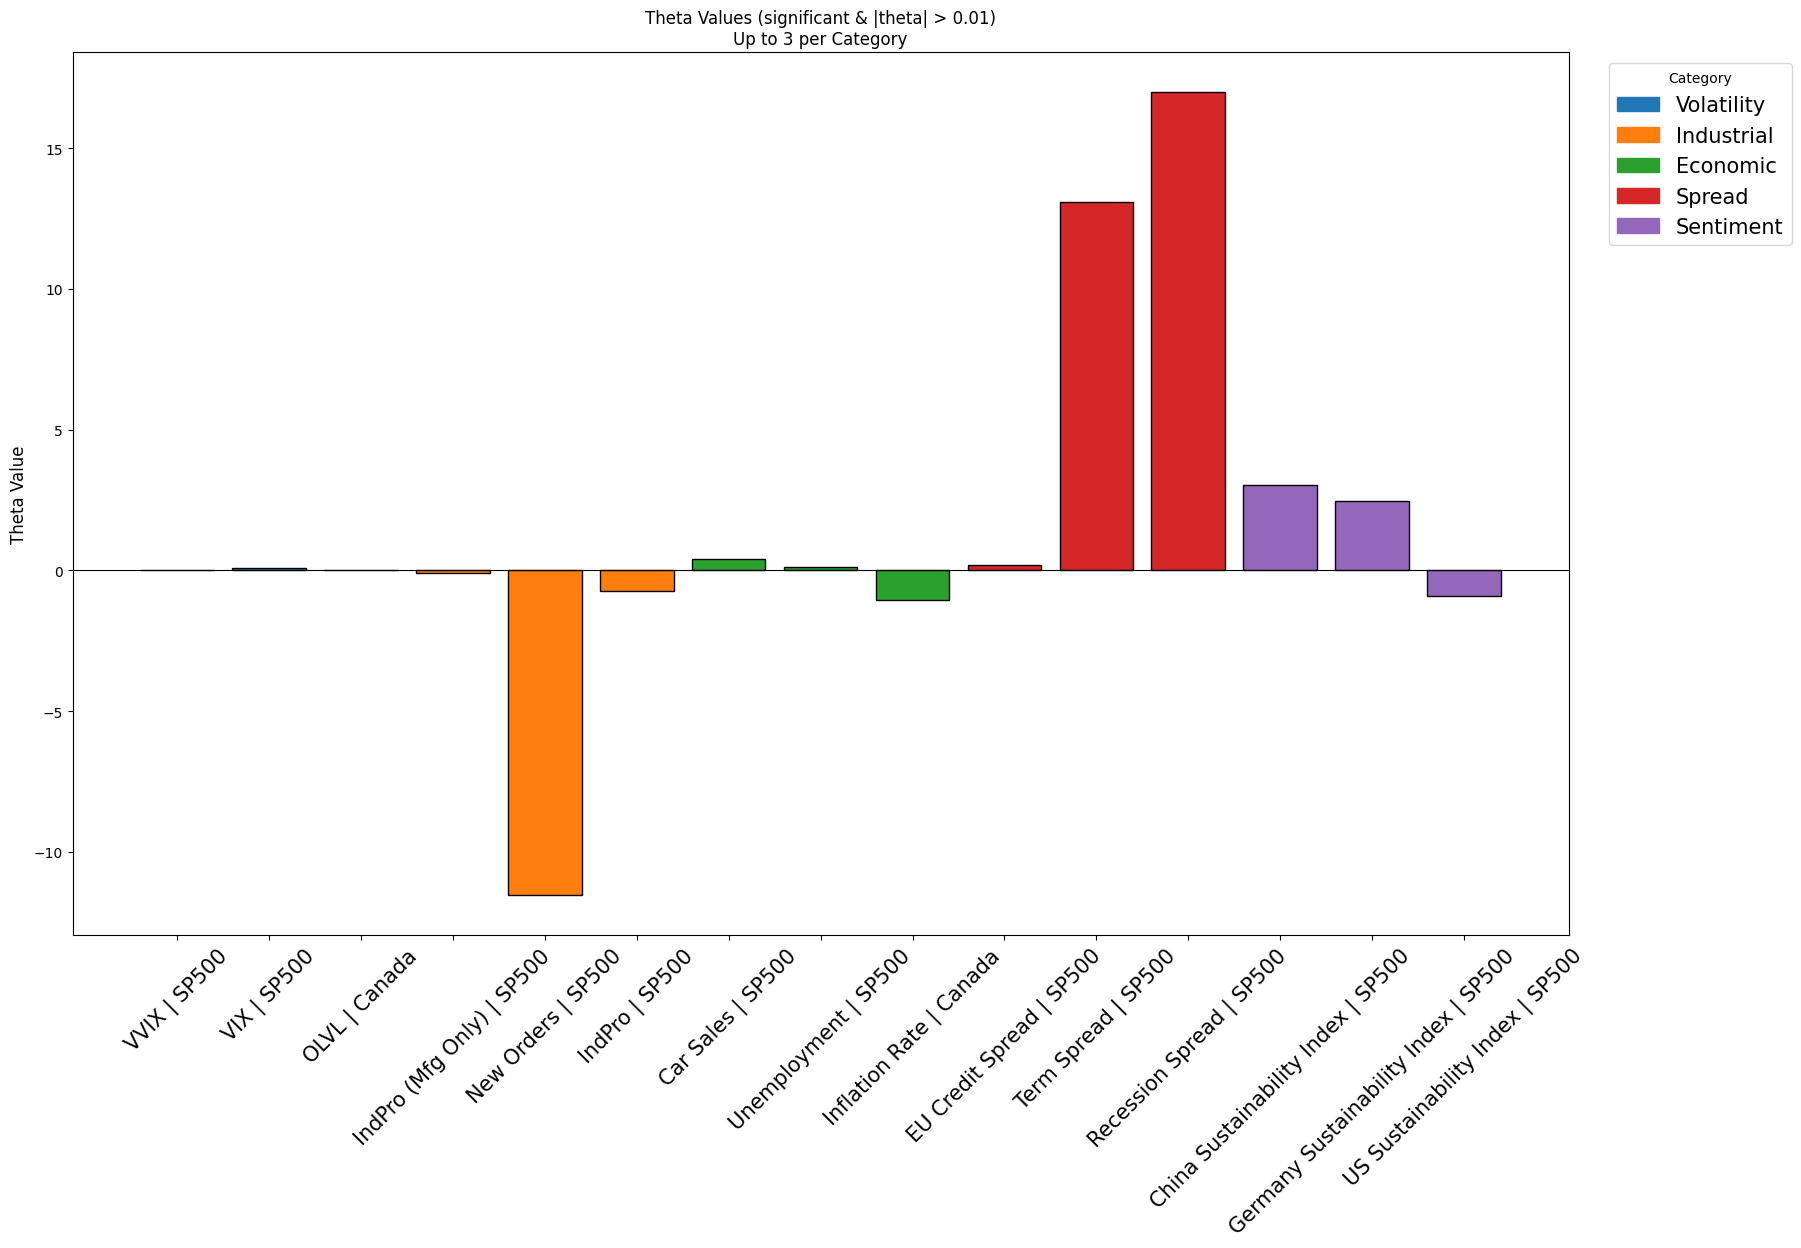

,avg_weight,vr_min,vr_max,vr_mean,vr_median,theta_median,count_significant,total_combos,pct_significant
Category,,,,,,,,,
Economic,6.73,48.15,220.95,108.99,85.96,0.15,31.0,65,47.69
Industrial,5.67,39.11,233.82,101.27,81.93,-0.08,44.0,78,56.41
Sentiment,2.48,33.22,252.82,105.09,86.36,-0.21,153.0,286,53.50
Spread,4.60,38.97,281.14,110.22,96.18,0.19,39.0,52,75.00
Volatility,5.87,37.22,233.61,96.16,86.39,0.02,45.0,78,57.69


In [603]:
summarize_midas_by_category(Overall_US_Indices, Category_Map, top_n_per_cat = 3)

## GARCH Analysis Functions

In [ ]:
def Reformat_GARCH_Analysis(df : pd.DataFrame,
                            index_names = None,
                            col_names = None,
                            return_by_Indice = False,
                            rename_mapping = rename_mapping):
    ''' 
    df <- do not parse anything or format anything
    MIDAS <- provide list of MIDAS variables in ORDER of how R does it
    returns <- provide list of returns in ORDER of how R does it
    '''
    if index_names is None:
        index_names = ['Alpha', 'Gamma', 'Beta', 'M', 'Theta', 'Weight']
        model_info_labels = [
            'Variance_Ratio', 'Q-Like', 'MSE',
            'AIC', 'BIC', 'Log_Likelihood'
             ]

    if col_names is None:
        col_names = ['Parameter', 'Value', 'StD Error', 'T-Stat', 'Pr < |t|', 'Combination', 'Model Info']
    
    df.columns = col_names
    df.drop_duplicates(inplace = True)

    """
    Reformats a flat GARCH-MIDAS DataFrame into a multi-index panel-style DataFrame with the following structure:
    - MultiIndex [MIDAS Variable, Return, Section, Metric]
    - Columns for relevant values

    'Model Info' will have a 6-row entry for each combination under 'Metric' with 'Value' column
    'Parameter Info' will have 6 rows under 'Metric' (parameter names) and 3 columns:
        ['Value', 'StD Error', 'Pr < |t|']
    """
    df['Parameter'] = df['Parameter'].apply(lambda x: re.sub(r'\d+$', '', x))

    model_info_labels = [
        'Variance_Ratio', 'Q-Like', 'MSE',
        'AIC', 'BIC', 'Log_Likelihood'
    ]

    panel_records = []

    for combo in df['Combination'].unique():
        sub_df = df[df['Combination'] == combo].copy().reset_index(drop=True)
        if len(sub_df) < 6:
            continue

        try:
            return_idx, midas_var = combo.split()
        except ValueError:
            continue

        for label, val in zip(model_info_labels, sub_df['Model Info'].values):
            panel_records.append([
                midas_var, return_idx, 'Model Info', label,
                val, None, None
            ])

        for _, row in sub_df.iterrows():
            param = row['Parameter']
            panel_records.append([
                midas_var, return_idx, 'Parameter Info', param,
                row['Value'], row['StD Error'], row['Pr < |t|']
            ])

    panel_df = pd.DataFrame(panel_records, columns=[
        'MIDAS Variable', 'Return', 'Section', 'Metric', 'Value', 'StD Error', 'Pr < |t|'
    ])
    panel_df.set_index(['MIDAS Variable', 'Return', 'Section', 'Metric'], inplace=True)

    panel_df.rename(index = rename_mapping, level = 0, inplace = True)
    
    return panel_df


In [ ]:
def visualize_midas_performance(panel_df, top_n=10, drop = False, figsize = (15, 15), fontsize = 14):
    ''' 
    This function creates a visualisation based on the theta parameter results. Theta measures the
    degree of impact that the long run volatility component plays within the overall volatility
    forecast.

    The variance ratio is the variance of the log(long-term volatility 1-step ahead values) divided 
    by the variance of the log(total conditional volatility). A higher variance ratio indicates
    more of the asset/indice/security's volatility is attributed to the long-run component.

    This plots:
        - Y axis : Average variance ratio among the stocks which has it's 3 highest variance ratios
        - X axis : Average variance ratio among the stocks which it is statistically significant
        - Bubble Size : Number of stocks which has a statistically significant theta value
    '''
    if drop == True:
        panel_df.drop(panel_df.index[panel_df.index.get_level_values('MIDAS Variable') == 'EquityVol'], inplace = True)
        panel_df.drop(panel_df.index[panel_df.index.get_level_values('MIDAS Variable') == 'EquityVolMeasure'], inplace=True)
    # Separates the statistically significant thetas 
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    theta_df = theta_df[theta_df['Pr < |t|'] < 0.05]
    
    # Number of Statistically significant indices
    sig_counts = theta_df.groupby('MIDAS Variable').size().reset_index(name='Significant_Count')

    avg_vr = (
        panel_df
        .xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))['Value']
        .groupby('MIDAS Variable')
        .mean()
        .reset_index(name='Avg_VR')
    )

    vr_data = (
        panel_df
        .xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))
        .reset_index()[['MIDAS Variable', 'Return', 'Value']]
    )

    top3_avg_vr = (
        theta_df[['MIDAS Variable', 'Return']]
        .drop_duplicates()
        .merge(vr_data, on=['MIDAS Variable', 'Return'])
        .sort_values(['MIDAS Variable', 'Value'], ascending=[True, False])
        .groupby('MIDAS Variable')
        .head(3)
        .groupby('MIDAS Variable')['Value']
        .mean()
        .reset_index(name='Top3_Avg_VR')
    )

    plot_df = sig_counts.merge(avg_vr, on='MIDAS Variable').merge(top3_avg_vr, on='MIDAS Variable')
    plot_df = plot_df.sort_values('Significant_Count', ascending=False).head(top_n)

    # Prepare plot
    plt.figure(figsize=figsize)
    # Linear regression line
    x = plot_df['Avg_VR'].values
    y = plot_df['Top3_Avg_VR'].values
    slope, intercept = np.polyfit(x, y, 1)
    print('slope', slope, intercept)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linestyle='--', color='grey', linewidth=2, label='Linear Fit')

    # Scatter bubble plot
    sns.scatterplot(
        data=plot_df,
        x='Avg_VR',
        y='Top3_Avg_VR',
        size='Significant_Count',
        hue='MIDAS Variable',
        sizes=(2000, 8000),
        alpha=0.7,
        edgecolor='black',
        linewidth=0.15,
        legend=False
    )

    # Annotations
    for _, row in plot_df.iterrows():
        plt.annotate(
            row['MIDAS Variable'],
            (row['Avg_VR'], row['Top3_Avg_VR']),
            fontsize=fontsize - 2, weight='bold', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6)
        )

    plt.title('MIDAS Variable Performance', fontsize=fontsize)
    plt.xlabel('Average Variance Ratio', fontsize=fontsize - 2)
    plt.ylabel('Top 3 Significant Variance Ratio (Average)', fontsize=fontsize - 2)
    plt.tight_layout()
    plt.show()

    return plot_df

In [ ]:
def plot_significant_counts_bar(panel_df):
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df.loc[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    theta_df = theta_df[theta_df['Pr < |t|'] < 0.05]

    sig_counts = theta_df.groupby('MIDAS Variable').size().reset_index(name='Significant_Count')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=sig_counts, x='MIDAS Variable', y='Significant_Count')
    plt.title('Number of Statistically Significant Theta Parameters by MIDAS Variable')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

    return sig_counts


def plot_average_weights(panel_df, ax, frequency='Monthly',
                         threshold=0.1, sig_level=0.05,
                         theta_pcol='Pr < |t|'):
    """
    Plots average & median MIDAS weights for variables whose theta val/param
    both exceeds `threshold` in absolute value AND is significant at `sig_level`.

    """

# 1. Extract only the "theta" rows under Section='Parameter Info'
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df[theta_df.index.get_level_values('Metric') == 'theta']
    
    # 2. Filter theta‐rows by absolute magnitude AND p-value
    #    (i.e. keep only those theta‐rows where |Value| > threshold AND p-value < sig_level)
    is_large = np.abs(theta_df['Value']) > threshold
    is_signif = theta_df[theta_pcol].astype(float) < sig_level
    filtered_theta = theta_df[is_large & is_signif]
    
    # 3. “valid_combos” are all (MIDAS Variable, Return, Parameter) combinations
    #    that survived. We drop only the 'Metric' level, leaving MIDAS Variable + whatever else.
    valid_combos = filtered_theta.index.droplevel(['Metric'])
    
    # 4. Now extract only the weight ("w") rows from Parameter Info
    weights_df = panel_df.xs('Parameter Info', level='Section')
    weights_df = weights_df[weights_df.index.get_level_values('Metric') == 'w']
    
    #    Filter weights to keep only those whose index (without 'Metric') is in valid_combos
    filtered_weights = weights_df[
        weights_df.index.droplevel(['Metric']).isin(valid_combos)
    ]
    
    # 5. Group by the MIDAS Variable to compute average & median of the weight values
    avg_weights = (
        filtered_weights
        .groupby(level='MIDAS Variable')['Value']
        .mean()
        .reset_index(name='Average_Weight')
    )
    median_weights = (
        filtered_weights
        .groupby(level='MIDAS Variable')['Value']
        .median()
        .reset_index(name='Median_Weight')
    )
    
    # 6. Merge the two summaries into one DataFrame for plotting
    temp_df = pd.merge(avg_weights, median_weights, on='MIDAS Variable')
    temp_df.set_index('MIDAS Variable', inplace=True)
    
    # 7. Plot a side-by-side bar chart of Average vs. Median weights
    temp_df.plot.bar(
        rot=30,
        ax=ax,
        legend=True,
        color=['darkgreen', 'crimson']
    )
    ax.set_title(
        f'Avg & Median MIDAS Weights\n'
        f'|θ| > {threshold}, p(theta) < {sig_level}'
    )
    ax.set_ylabel(f'Periods ({frequency})')
    ax.set_xlabel('MIDAS Variable')
    ax.set_xticklabels(temp_df.index, rotation=45, ha='right')
    
    return avg_weights, median_weights

In [ ]:
def plot_midas_vr_per_return(panel_df, top_n=5, drop_vars=None):
    """
    Horizontal bar chart of the top_n absolute Variance Ratios per Return,
    including only those MIDAS variables whose theta-coefficient p-value is < 0.05.

    - panel_df: a MultiIndex DataFrame indexed by
        (MIDAS Variable, Return, Section, Metric)
      and with a “Value” column containing the numeric entries.
    - Variance Ratio is stored under Section='Parameter Info', Metric='Variance_Ratio'.
    - Theta’s p-value is stored under Section='Model Info', Metric='Pr < |t|'.

    - drop_vars: list of MIDAS variable names to exclude before plotting.
    """
    # 1) Extract theta p-values (Section='Model Info', Metric='Pr < |t|')
    pval_df = panel_df.xs(
        ('Parameter Info', 'theta'),
        level=('Section', 'Metric')
    )[['Pr < |t|']].reset_index()   # columns: ['MIDAS Variable', 'Return', 'Pr < |t|']

    # Rename the p-value column for clarity
    pval_df = pval_df.rename(columns={'Pr < |t|': 'Theta_pval'})

    # Optionally drop unwanted MIDAS variables
    if drop_vars:
        pval_df = pval_df[~pval_df['MIDAS Variable'].isin(drop_vars)]

    # 2) Keep only those (Return, MIDAS Variable) pairs with p < 0.05
    sig_df = pval_df[pval_df['Theta_pval'] < 0.05].copy()

    # 3) Extract Variance Ratios (Section='Parameter Info', Metric='Variance_Ratio')

    vr_df = panel_df.xs(
        ('Model Info', 'Variance_Ratio'),
        level=('Section', 'Metric')
    )['Value'].reset_index()

    vr_df = vr_df.rename(columns={'Value': 'Variance Ratio'})

    # Optionally drop the same unwanted MIDAS variables from VR
    if drop_vars:
        vr_df = vr_df[~vr_df['MIDAS Variable'].isin(drop_vars)]

    # 4) Merge VR with the “significant-only” filter
    #    This keeps only rows whose (Return, MIDAS Variable) appear in sig_df
    merged = pd.merge(
        vr_df,
        sig_df[['MIDAS Variable', 'Return']],
        on=['MIDAS Variable', 'Return'],
        how='inner'
    )

    # 5) Compute absolute VR and pick top_n per return
    merged['Abs_VR'] = merged['Variance Ratio'].abs()
    grouped = merged.groupby('Return', group_keys=False)
    top_df = grouped.apply(lambda df: df.nlargest(top_n, 'Abs_VR')).reset_index(drop=True)

    # 6) Prepare for plotting
    returns = top_df['Return'].unique().tolist()
    unique_vars = top_df['MIDAS Variable'].unique().tolist()
    colors = sns.color_palette(n_colors=len(unique_vars))
    color_map = dict(zip(unique_vars, colors))

    fig, ax = plt.subplots(figsize=(10, max(6, len(returns)*1.5)))

    # 7) Plot bars per return, side-by-side
    for i, ret in enumerate(returns):
        sub = top_df[top_df['Return'] == ret].copy()
        m = len(sub)
        if m == 0:
            continue

        # Distribute bar centers around i (vertically)
        bar_height = 0.8 / m
        offsets = np.linspace(-0.4 + bar_height/2, 0.4 - bar_height/2, m)

        for j, (_, row) in enumerate(sub.iterrows()):
            y = i + offsets[j]
            ax.barh(
                y,
                row['Abs_VR'],
                height=bar_height,
                color=color_map[row['MIDAS Variable']],
                edgecolor='black'
            )
            # Annotate each bar with the MIDAS variable name
            ax.text(
                row['Abs_VR'] + 0.005 * top_df['Abs_VR'].max(),
                y,
                row['MIDAS Variable'],
                va='center',
                ha='left',
                fontsize=9
            )

    # 8) Final formatting
    ax.set_yticks(range(len(returns)))
    ax.set_yticklabels(returns, fontsize=10)
    ax.set_xlabel('Absolute Variance Ratio', fontsize=12)
    ax.set_title(f'Top {top_n} Significant MIDAS Variables by Absolute VR per Return',
                 fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return top_df

In [ ]:
def plot_return_level_stats(panel_df, threshold=0.05):
    """
    Plots, for each Return, the number of MIDAS variables with statistically significant theta (Pr < |t| < threshold)
    and the average variance ratio of those significant variables.

    Parameters:
    - panel_df: MultiIndex DataFrame with levels [MIDAS Variable, Return, Section, Metric]
    - threshold: float, significance cutoff for theta's 'Pr < |t|' value

    Returns:
    - stats_df: DataFrame with columns ['Return', 'Significant_Count', 'Avg_VR']
    """
    # Extract theta parameter rows and filter by significance
    theta_df = panel_df.xs('Parameter Info', level='Section')
    theta_df = theta_df[theta_df.index.get_level_values('Metric') == 'theta']
    theta_df = theta_df.reset_index()
    sig = theta_df[theta_df['Pr < |t|'] < threshold]

    # Count of significant MIDAS variables per Return
    combos = sig[['MIDAS Variable', 'Return']].drop_duplicates()
    sig_counts = combos.groupby('Return').size().reset_index(name='Significant_Count')

    # Extract variance ratio model info
    vr = panel_df.xs(('Model Info', 'Variance_Ratio'), level=('Section', 'Metric'))['Value']
    vr = vr.reset_index()[['MIDAS Variable', 'Return', 'Value']]

    # Compute average variance ratio for significant combos per Return
    merged = combos.merge(vr, on=['MIDAS Variable', 'Return'])

    avg_vr = merged.groupby('Return')['Value'].mean().reset_index(name='Avg_VR')

    # Combine counts and averages
    stats_df = sig_counts.merge(avg_vr, on='Return')

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=stats_df,
        x='Return',
        y='Significant_Count',
        color='skyblue',
        ax=ax1
    )
    ax1.set_xlabel('Return')
    ax1.set_ylabel('Significant MIDAS Count', color='skyblue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(
        data=stats_df,
        x='Return',
        y='Avg_VR',
        marker='o',
        color='darkorange',
        ax=ax2
    )
    ax2.set_ylabel('Average Variance Ratio', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    plt.title(f'Return-level Stats (theta threshold = {threshold})')
    fig.tight_layout()
    plt.show()

    return stats_df

In [ ]:
plot_df.set_index('MIDAS Variable', inplace = True)

html_str = plot_df.sort_values('Significant_Count', ascending = False).round(4).to_html(bold_rows=True)

with open("5.4.3.html", "w") as f:
    f.write(html_str)


## Overall Analysis

In [ ]:
%matplotlib inline
plot_df = visualize_midas_performance(Overall_US_Indices, top_n = 12, drop = False, figsize = (12, 10), fontsize = 15)

fig, axes = plt.subplots(1, figsize = (20, 10))
plot_average_weights(Overall_US_Indices, ax = axes, threshold = 0)
top_df = plot_midas_vr_per_return(Overall_US_Indices)
plot_return_level_stats(Overall_US_Indices)
plt.tight_layout()

### Sector Indices

In [ ]:
Sector_Indices = pd.concat([Sentiment_Sector_Indices, Volatility_Sector_Indices, Industrial_Sector_Indices, Economic_Sector_Indices, Spread_Sector_Indices])
Sector_Indices = Reformat_GARCH_Analysis(Sector_Indices)

plot_df = visualize_midas_performance(Sector_Indices, top_n = 12, drop = False, figsize = (10,10))

fig, axes = plt.subplots(1, figsize = (20, 10))
plot_average_weights(Sector_Indices, ax = axes, threshold = 0.1)
top_df = plot_midas_vr_per_return(Sector_Indices, top_n = 5)

plt.tight_layout()

### US Indices 

In [ ]:
US_Indices = pd.concat([Sentiment_US_Indices, Volatility_US_Indices, Industrial_US_Indices, Economic_US_Indices, Spread_US_Indices])
US_Indices = Reformat_GARCH_Analysis(US_Indices)

visualize_midas_performance(US_Indices, top_n = 12, drop = False, figsize = (10, 10))

fig, axes = plt.subplots(1, figsize = (20, 10))
plot_average_weights(US_Indices, ax = axes, threshold = 0.1)
plot_midas_vr_per_return(US_Indices)

plot_return_level_stats(US_Indices)
plt.tight_layout()

## Index Analysis

### Sentiment Based Indicators

In [ ]:
# US and Sector Indices
df = Reformat_GARCH_Analysis(pd.concat([Sentiment_US_Indices, Sentiment_Sector_Indices]))

plot_df = visualize_midas_performance(df, figsize = (12,12), fontsize = 14)

plot_midas_vr_per_return(df, 3)

plot_return_level_stats(df)

plot_significant_counts_bar(df)

fig, axs = plt.subplots(2 ,2, figsize = (15, 20))
thresholds = np.arange(0, 2, 0.5)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df, axes[count], threshold = threshold, frequency = 'Monthly')

plt.tight_layout()

In [ ]:
df = Reformat_GARCH_Analysis(Sentiment_Sector_Indices)

fig, axs = plt.subplots(1,2, figsize = (15, 8))
thresholds = np.arange(0, 0.5, .25)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df, axes[count], threshold = threshold, frequency = 'Monthly')
    axes[count].set_xlabel('')



### Volatility Based Indicators

In [ ]:
df = Reformat_GARCH_Analysis(pd.concat([Volatility_US_Indices, Volatility_Sector_Indices]))
fig, axs = plt.subplots(1, figsize = (10, 10))

plot_average_weights(df, axs, threshold = 0.0, frequency = 'Monthly', sig_level = 0.05)

plot_return_level_stats(df)

# Sector
plot_midas_vr_per_return(Reformat_GARCH_Analysis(Volatility_Sector_Indices), 3)

# US Indices
plot_midas_vr_per_return(Reformat_GARCH_Analysis(Volatility_US_Indices), 3)

plot_df = visualize_midas_performance(df, figsize = (10,10))

#### US Indices

In [ ]:
df = Reformat_GARCH_Analysis(Volatility_US_Indices)
visualize_midas_performance(df)

fig, axs = plt.subplots(1, figsize = (10, 10))


plot_midas_vr_per_return(df, top_n = 3)
plt.tight_layout()

#### Sector Indices

In [ ]:
df = Reformat_GARCH_Analysis(Volatility_Sector_Indices)
visualize_midas_performance(df, fontsize = 16, figsize = (12,12))

plot_significant_counts_bar(df)

plot_midas_vr_per_return(df, top_n = 3)

plt.tight_layout()

### Industrial Indicators

In [ ]:
df = Reformat_GARCH_Analysis(pd.concat([Industrial_Sector_Indices, Industrial_US_Indices]))

plot_df = visualize_midas_performance(df, figsize = (12,12), fontsize = 14)

plot_midas_vr_per_return(Reformat_GARCH_Analysis(Industrial_Sector_Indices))
plot_midas_vr_per_return(Reformat_GARCH_Analysis(Industrial_US_Indices))



#### Sector Indices

In [ ]:
df = Reformat_GARCH_Analysis(Industrial_Sector_Indices, Industrial_US_Indices)

plot_midas_vr_per_return(df, top_n = 3)

plot_return_level_stats(df)

plot

In [ ]:
fig, axs = plt.subplots(1, figsize = (20, 10))
plot_average_weights(df, axs, threshold = 0.0, frequency = 'Monthly')
plt.xticks(size = 15)

#### US Indices

In [ ]:
df = Reformat_GARCH_Analysis(Industrial_US_Indices)
visualize_midas_performance(df, figsize = (9,9), fontsize = 12)

In [ ]:
fig, axs = plt.subplots(1, figsize = (10, 10))

plot_average_weights(df, axs, threshold = 0, frequency = 'Monthly')


In [ ]:
plot_return_level_stats(df)

In [ ]:
plot_midas_vr_per_return(df, top_n = 4)

### Economic Indicators

In [ ]:
df1 = Reformat_GARCH_Analysis(pd.concat([Economic_Sector_Indices, Economic_US_Indices]))
plot_df = visualize_midas_performance(df1, figsize = (10,10), fontsize = 15)

plot_return_level_stats(df1)

In [ ]:
df = Reformat_GARCH_Analysis(Economic_Sector_Indices)

fig, ax = plt.subplots(1, figsize = (12,10))

plot_average_weights(df, ax)


plot_midas_vr_per_return(df)



In [ ]:
plot_midas_vr_per_return(Reformat_GARCH_Analysis(Economic_Sector_Indices))

#### Sector Indices

In [ ]:
df = Reformat_GARCH_Analysis(Economic_Sector_Indices)
visualize_midas_performance(df, figsize = (12,12), fontsize = 15)



fig, axs = plt.subplots(1,2, figsize = (15, 10))

plot_average_weights(df, axs[0], threshold = 0, frequency = 'Monthly')
plot_average_weights(df, axs[1], threshold = 0.5, frequency = 'Monthly')
plot_midas_vr_per_return(df, top_n = 5)

plt.tight_layout()

#### US Indices

In [ ]:
df = Reformat_GARCH_Analysis(Economic_US_Indices)
visualize_midas_performance(df, figsize = (10, 10), fontsize = 15)

In [ ]:
fig, axs = plt.subplots(1, 1, figsize = (12, 12))
plot_average_weights(df, axs, threshold = 0, frequency = 'Monthly')
plot_midas_vr_per_return(df)
plt.tight_layout()

In [ ]:
plot_midas_vr_per_return(df, top_n = 3)


In [ ]:
plot_significant_counts_bar(df)

In [ ]:
plot_return_level_stats(df)

In [ ]:
df = Reformat_GARCH_Analysis()

fig, axs = plt.subplots(4, 1, figsize = (10, 40))
thresholds = np.arange(0, 0.8, 0.2)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    print(threshold)
    plot_average_weights(df, axes[count], threshold = threshold, frequency = 'Monthly')


plot_midas_vr_per_return(df, top_n = 3)

plot_significant_counts_bar(df)

plot_return_level_stats

### Spread Indicators

In [ ]:
df = Reformat_GARCH_Analysis(pd.concat([Spread_US_Indices, Spread_Sector_Indices]))
plot_midas_vr_per_return(df)
plot_return_level_stats(df)

#### Sector Indices

In [ ]:
df = Reformat_GARCH_Analysis(Spread_US_Indices)

fig, axs = plt.subplots(1, 2, figsize = (16, 10))
thresholds = np.arange(0, 0.5, 0.25)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df, axes[count], threshold = threshold, frequency = 'Monthly')



plt.tight_layout()

In [ ]:
plot_midas_vr_per_return(Reformat_GARCH_Analysis(Spread_Sector_Indices), top_n = 4)

#### US Indices

In [ ]:
df = Reformat_GARCH_Analysis(Spread_US_Indices)
visualize_midas_performance(df, figsize = (10,10), fontsize = 16)

plot_significant_counts_bar(df)

fig, axs = plt.subplots(1, 2, figsize = (10, 10))
thresholds = np.arange(0, 0.5, 0.25)
axes = axs.flatten()

for count, threshold in enumerate(thresholds):
    plot_average_weights(df, axes[count], threshold = threshold, frequency = 'Monthly')

plot_midas_vr_per_return(df, top_n = 4)

plt.tight_layout()